In [24]:
import pandas as pd
import numpy as np
import sys
sys.path.append('../')

In [16]:
customers = pd.read_csv('../data/customers.csv')
orders = pd.read_csv('../data/orders.csv')
products = pd.read_csv('../data/products.csv')

In [17]:
print("Customers:")
print(customers.shape)
print(customers.info())
print(customers.describe())
print(customers.isnull().sum())

Customers:
(500, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  500 non-null    object 
 1   name         500 non-null    object 
 2   email        500 non-null    object 
 3   age          460 non-null    float64
 4   city         500 non-null    object 
 5   gender       470 non-null    object 
 6   signup_date  500 non-null    object 
dtypes: float64(1), object(6)
memory usage: 27.5+ KB
None
              age
count  460.000000
mean    41.245652
std     13.312667
min     18.000000
25%     30.750000
50%     42.000000
75%     52.000000
max     64.000000
customer_id     0
name            0
email           0
age            40
city            0
gender         30
signup_date     0
dtype: int64


In [18]:
print("\nOrders:")
print(orders.shape)
print(orders.info())
print(orders.describe())
print(orders.isnull().sum())


Orders:
(1500, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   order_id      1500 non-null   object
 1   customer_id   1500 non-null   object
 2   product_id    1500 non-null   object
 3   order_date    1500 non-null   object
 4   quantity      1500 non-null   int64 
 5   discount_pct  1500 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 70.4+ KB
None
          quantity  discount_pct
count  1500.000000   1500.000000
mean      3.034000     17.646667
std       1.426722     12.456535
min       1.000000      0.000000
25%       2.000000      5.000000
50%       3.000000     15.000000
75%       4.000000     25.000000
max       5.000000     40.000000
order_id        0
customer_id     0
product_id      0
order_date      0
quantity        0
discount_pct    0
dtype: int64


In [19]:
print("\nProducts:")
print(products.shape)
print(products.info())
print(products.describe())
print(products.isnull().sum())


Products:
(80, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    80 non-null     object 
 1   product_name  80 non-null     object 
 2   category      80 non-null     object 
 3   price         80 non-null     object 
 4   rating        68 non-null     float64
dtypes: float64(1), object(4)
memory usage: 3.3+ KB
None
          rating
count  68.000000
mean    3.294118
std     1.121550
min     1.500000
25%     2.200000
50%     3.350000
75%     4.325000
max     5.000000
product_id       0
product_name     0
category         0
price            0
rating          12
dtype: int64


In [20]:
def null_report(df, name):
    null_counts = df.isnull().sum()
    null_percentages = (null_counts / len(df)) * 100
    print(f"=== Null Report: {name} ===")
    for column, count, percentage in zip(null_counts.index, null_counts, null_percentages):
        print(f"{column} → {count} nulls ({percentage:.2f}%)")


In [28]:
from utils import classify_customer

print("Before Cleaning:")
null_report(customers, 'customers')
null_report(orders, 'orders')
null_report(products, 'products')

customers['age'] = customers['age'].fillna(customers['age'].median())
customers['gender'] = customers['gender'].fillna('Unknown')
customers = customers.drop_duplicates(subset='email', keep='first')
customers['gender'] = customers['gender'].astype('category')
customers['age_group'] = customers['age'].apply(classify_customer)

products['price'] = products['price'].astype(str).str.replace('₹', '').str.strip().astype(float)
products['rating'] = products['rating'].fillna(products['rating'].mean().round(1))
products['category'] = products['category'].astype('category')

customers.to_csv('../outputs/cleaned_customers.csv', index=False)
# products.to_csv('../outputs/cleaned_products.csv', index=False)
# orders.to_csv('../outputs/cleaned_orders.csv', index=False)

print("\nAfter Cleaning:")
null_report(customers, 'customers')
null_report(orders, 'orders')
null_report(products, 'products')

Before Cleaning:
=== Null Report: customers ===
customer_id → 0 nulls (0.00%)
name → 0 nulls (0.00%)
email → 0 nulls (0.00%)
age → 0 nulls (0.00%)
city → 0 nulls (0.00%)
gender → 0 nulls (0.00%)
signup_date → 0 nulls (0.00%)
age_group → 0 nulls (0.00%)
=== Null Report: orders ===
order_id → 0 nulls (0.00%)
customer_id → 0 nulls (0.00%)
product_id → 0 nulls (0.00%)
order_date → 0 nulls (0.00%)
quantity → 0 nulls (0.00%)
discount_pct → 0 nulls (0.00%)
=== Null Report: products ===
product_id → 0 nulls (0.00%)
product_name → 0 nulls (0.00%)
category → 0 nulls (0.00%)
price → 0 nulls (0.00%)
rating → 0 nulls (0.00%)

After Cleaning:
=== Null Report: customers ===
customer_id → 0 nulls (0.00%)
name → 0 nulls (0.00%)
email → 0 nulls (0.00%)
age → 0 nulls (0.00%)
city → 0 nulls (0.00%)
gender → 0 nulls (0.00%)
signup_date → 0 nulls (0.00%)
age_group → 0 nulls (0.00%)
=== Null Report: orders ===
order_id → 0 nulls (0.00%)
customer_id → 0 nulls (0.00%)
product_id → 0 nulls (0.00%)
order_date → 

In [30]:
# Task 3.1 — Revenue Array
prices = products['price'].to_numpy()
price_with_tax = prices * 1.18
final_price = price_with_tax * 0.90

print("Final Price:")
print("Shape:", final_price.shape)
print("Dtype:", final_price.dtype)
print("First 5 values:", final_price[:5])


Final Price:
Shape: (80,)
Dtype: float64
First 5 values: [1075.806 4592.088 2370.384 5067.864 4899.006]


In [31]:
# Task 3.2 — Reshape Exercise
first_20_prices = final_price[:20]
reshaped_prices = first_20_prices.reshape(4, 5)
transposed_prices = reshaped_prices.T
flattened_prices = transposed_prices.flatten()

print("\nReshaped Prices (4, 5):")
print(reshaped_prices)
print("\nTransposed Prices:")
print(transposed_prices)
print("\nFlattened Prices:")
print(flattened_prices)


Reshaped Prices (4, 5):
[[1075.806 4592.088 2370.384 5067.864 4899.006]
 [ 471.528 5301.504  500.202 3941.082 2093.202]
 [1552.644 2786.688 4843.782 1189.44  3855.06 ]
 [4922.37  4974.408 2999.088 4205.52  2389.5  ]]

Transposed Prices:
[[1075.806  471.528 1552.644 4922.37 ]
 [4592.088 5301.504 2786.688 4974.408]
 [2370.384  500.202 4843.782 2999.088]
 [5067.864 3941.082 1189.44  4205.52 ]
 [4899.006 2093.202 3855.06  2389.5  ]]

Flattened Prices:
[1075.806  471.528 1552.644 4922.37  4592.088 5301.504 2786.688 4974.408
 2370.384  500.202 4843.782 2999.088 5067.864 3941.082 1189.44  4205.52
 4899.006 2093.202 3855.06  2389.5  ]


In [35]:
import sqlite3
conn = sqlite3.connect('../outputs/retailsense.db')
customers.to_sql('customers', conn, if_exists='replace', index=False)
products.to_sql('products', conn, if_exists='replace', index=False)
orders.to_sql('orders', conn, if_exists='replace', index=False)
print("Q1: How many customers are from each city? Sort by count descending.")
print(pd.read_sql_query("""
    SELECT city, COUNT(*) as customer_count
    FROM customers
    GROUP BY city
    ORDER BY customer_count DESC
""", conn))
print("\nQ2: Top 5 most expensive products?")
print(pd.read_sql_query("""
    SELECT product_name, price
    FROM products
    ORDER BY price DESC
    LIMIT 5
""", conn))
print("\nQ3: Orders with discount greater than 20%?")
print(pd.read_sql_query("""
    SELECT order_id, customer_id, discount_pct
    FROM orders
    WHERE discount_pct > 20
""", conn))

print("\nQ4: Average rating per product category?")
print(pd.read_sql_query("""
    SELECT category, AVG(rating) as avg_rating
    FROM products
    GROUP BY category
""", conn))

print("\nQ5: Categories with more than 10 products AND average rating above 3.5?")
print(pd.read_sql_query("""
    SELECT category, COUNT(*) as product_count, AVG(rating) as avg_rating
    FROM products
    GROUP BY category
    HAVING COUNT(*) > 10 AND AVG(rating) > 3.5
""", conn))

print("\nQ6: For each order, show customer name, product name, quantity, and base price?")
print(pd.read_sql_query("""
    SELECT c.name, p.product_name, o.quantity, p.price
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN products p ON o.product_id = p.product_id
""", conn))

print("\nQ7: Customers who have placed no orders?")
print(pd.read_sql_query("""
    SELECT c.name, c.email
    FROM customers c
    LEFT JOIN orders o ON c.customer_id = o.customer_id
    WHERE o.order_id IS NULL
""", conn))


Q1: How many customers are from each city? Sort by count descending.
        city  customer_count
0  Hyderabad              86
1    Kolkata              76
2       Pune              74
3  Bengaluru              67
4      Delhi              65
5    Chennai              64
6     Mumbai              58

Q2: Top 5 most expensive products?
  product_name   price
0    Product_7  4992.0
1   Product_73  4875.0
2    Product_4  4772.0
3   Product_30  4694.0
4   Product_17  4684.0

Q3: Orders with discount greater than 20%?
    order_id customer_id  discount_pct
0     O00002       C0209            25
1     O00005       C0431            30
2     O00010       C0061            40
3     O00016       C0367            25
4     O00017       C0150            30
..       ...         ...           ...
528   O01492       C0496            30
529   O01495       C0342            40
530   O01498       C0034            30
531   O01499       C0282            25
532   O01500       C0278            40

[533 rows x 

In [38]:
# Part 5 — Advanced Pandas: GroupBy & Pivot
from utils import calculate_revenue
full_df = pd.merge(orders, customers, on='customer_id')
full_df = pd.merge(full_df, products, on='product_id')

full_df['revenue'] = full_df.apply(lambda row: calculate_revenue(row['price'], row['quantity'], row['discount_pct']), axis=1)

print("Total revenue per product category:")
print(full_df.groupby('category')['revenue'].sum())

print("\nAverage order quantity per city:")
print(full_df.groupby('city')['quantity'].mean())

print("\nTop 3 customers by total revenue:")
print(full_df.groupby('name')['revenue'].sum().nlargest(3))

print("\nCustom aggregation: For each category, calculate total revenue, number of unique customers, average discount")
print(full_df.groupby('category').agg({
    'revenue': 'sum',
    'customer_id': 'nunique',
    'discount_pct': 'mean'
}))
print("\nPivot table: revenue by category and age group")
print(full_df.pivot_table(values='revenue', index='category', columns='age_group', aggfunc='sum', fill_value=0))


Total revenue per product category:
category
Books          3027171.30
Clothing       1662080.50
Electronics    2064215.45
Food           2146158.55
Name: revenue, dtype: float64

Average order quantity per city:
city
Bengaluru    2.801843
Chennai      3.096447
Delhi        3.033333
Hyderabad    3.102222
Kolkata      3.094059
Mumbai       3.005525
Pune         3.067227
Name: quantity, dtype: float64

Top 3 customers by total revenue:
name
Customer_228    82347.30
Customer_348    64290.90
Customer_59     60649.15
Name: revenue, dtype: float64

Custom aggregation: For each category, calculate total revenue, number of unique customers, average discount
                revenue  customer_id  discount_pct
category                                          
Books        3027171.30          280     17.253363
Clothing     1662080.50          193     16.823529
Electronics  2064215.45          247     18.315508
Food         2146158.55          272     17.405063

Pivot table: revenue by category an

C:\Users\varsh\AppData\Local\Temp\ipykernel_27816\4237219281.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(full_df.groupby('category')['revenue'].sum())
C:\Users\varsh\AppData\Local\Temp\ipykernel_27816\4237219281.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(full_df.groupby('category').agg({
C:\Users\varsh\AppData\Local\Temp\ipykernel_27816\4237219281.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  print(full_df.pivot

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



C:\Users\varsh\AppData\Local\Temp\ipykernel_27816\548473590.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.barplot(x='category', y='revenue', data=full_df.groupby('category')['revenue'].sum().reset_index())


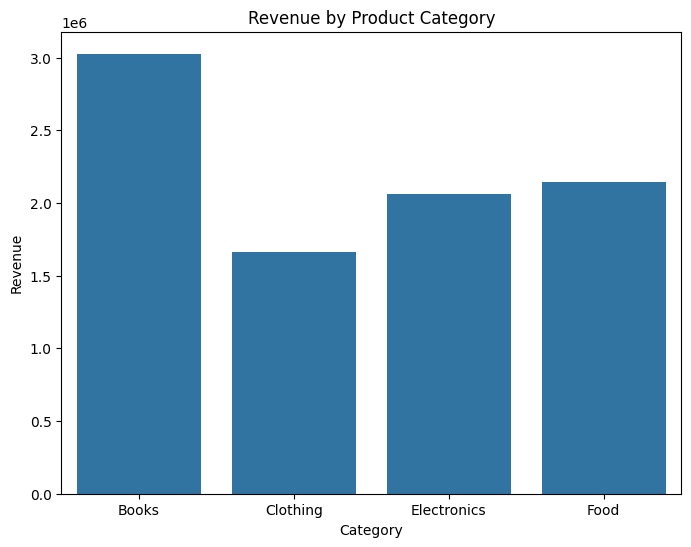

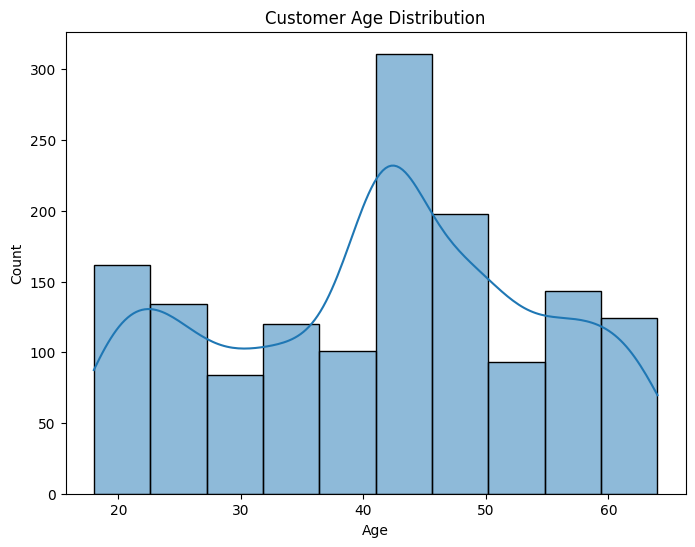

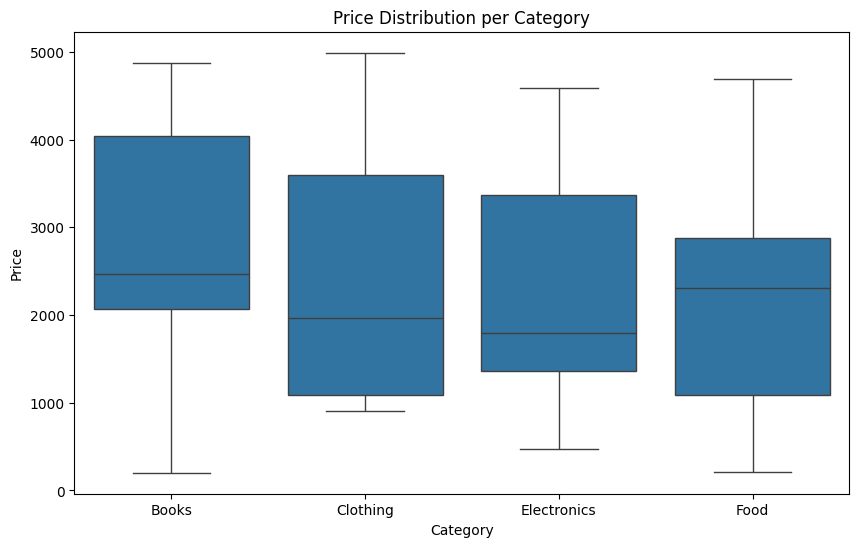

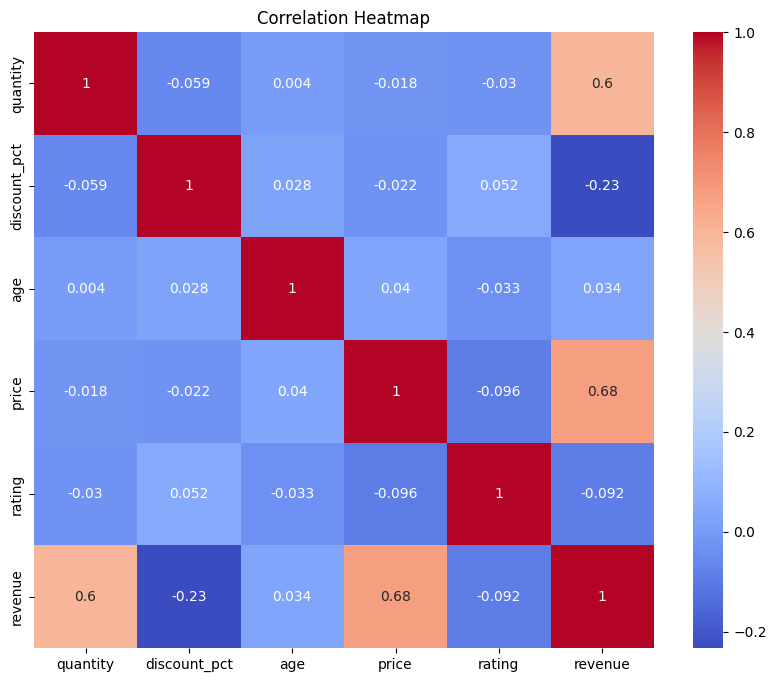

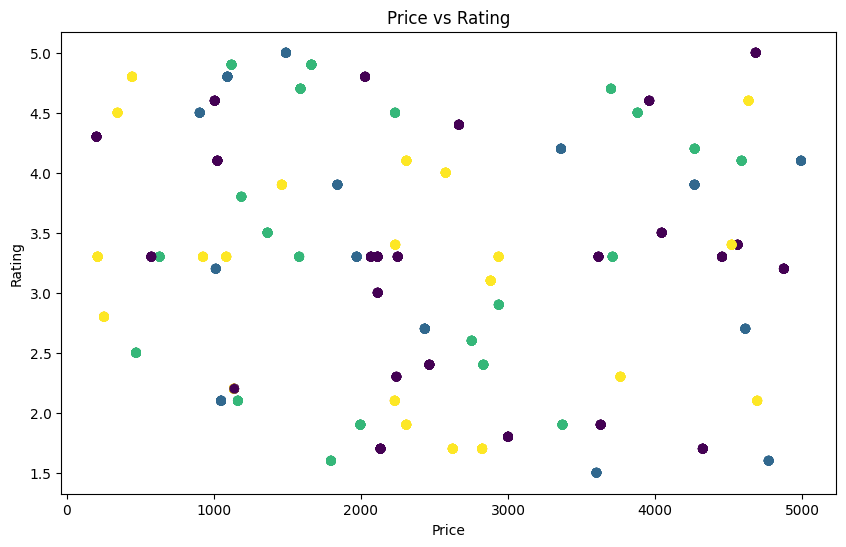

In [57]:
# Part 6 — Data Visualization
#P1: Revenue by product category
plt.figure(figsize=(8, 6))
sns.barplot(x='category', y='revenue', data=full_df.groupby('category')['revenue'].sum().reset_index())
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

# P2: Customer age distribution
plt.figure(figsize=(8, 6))
sns.histplot(full_df['age'], bins=10, kde=True)
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# P3: Price distribution per category
plt.figure(figsize=(10, 6))
sns.boxplot(x='category', y='price', data=full_df)
plt.title('Price Distribution per Category')
plt.xlabel('Category')
plt.ylabel('Price')
plt.show()

# P4: Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(full_df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# P5: Interactive scatter: Price vs Rating
plt.figure(figsize=(10, 6))
plt.scatter(full_df['price'], full_df['rating'], c=full_df['category'].astype('category').cat.codes)
plt.xlabel('Price')
plt.ylabel('Rating')
plt.title('Price vs Rating')
plt.show()



In [50]:
import requests
import json

In [52]:
# Task 7.1 — Test a Public API
response = requests.get('https://jsonplaceholder.typicode.com/users')
users = response.json()
for user in users:
    print(user['name'], user['email'], user['address']['city'])

# Task 7.2 — POST Request Practice
post_data = {'title': 'RetailSense Report', 'body': 'Q4 revenue exceeded targets by 12%', 'userId': 1}
response = requests.post('https://jsonplaceholder.typicode.com/posts', json=post_data)
print(response.status_code)
print(response.json()['id'])

# Task 7.3 — Save API Data to File
with open('../outputs/api_users.json', 'w') as f:
    json.dump(users, f)
with open('../outputs/api_users.json', 'r') as f:
    loaded_users = json.load(f)
print(loaded_users[0]['name'])

Leanne Graham Sincere@april.biz Gwenborough
Ervin Howell Shanna@melissa.tv Wisokyburgh
Clementine Bauch Nathan@yesenia.net McKenziehaven
Patricia Lebsack Julianne.OConner@kory.org South Elvis
Chelsey Dietrich Lucio_Hettinger@annie.ca Roscoeview
Mrs. Dennis Schulist Karley_Dach@jasper.info South Christy
Kurtis Weissnat Telly.Hoeger@billy.biz Howemouth
Nicholas Runolfsdottir V Sherwood@rosamond.me Aliyaview
Glenna Reichert Chaim_McDermott@dana.io Bartholomebury
Clementina DuBuque Rey.Padberg@karina.biz Lebsackbury
201
101
Leanne Graham


In [ ]:
# Part 9 — Ethics & Privacy Audit

### PII Identification
# - customers.csv: 
#   - email (PII): Hash or mask before sharing externally
#   - name (PII): Hash or mask before sharing externally
#   - age (PII): Consider binning or masking for external sharing
#   - city (PII): Mask or generalize (e.g., state level) before sharing
# - orders.csv: customer_id (links to PII) - use mapping for external sharing
# - products.csv: no PII

### Anonymization Plan
# 1. Hash email and name columns in customers.csv
# 2. Mask or generalize city (e.g., state level)
# 3. Use customer_id mapping instead of linking directly for orders.csv
# 4. Remove or mask any other sensitive fields as needed

### API Ethics
# 1. Check API terms of service for usage limits and restrictions
# 2. Ensure API key is secure and not exposed
# 3. Handle errors and exceptions properly to avoid impacting API services

### Null Handling Choice
# Filling null ages with median could introduce bias if data is not missing randomly.
# Alternative: use multiple imputation or model-based imputation for more accuracy.